# Automobile Sales Pipeline Risk Analysis

## Business Question
Where is revenue being lost or delayed across our order pipeline, 
and which regions, customers, and product lines carry the most risk 
from cancelled, disputed, and on-hold orders?

## Dataset
- Source: Kaggle — Automobile Sales Dataset
- 2,747 order line items across 298 unique orders
- 19 countries
- Date range: 01/03/2020 to 31/05/2020

## Key Findings
- To be completed after analysis

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Auto Sales data.csv')

## 1. Pipeline Overview — Revenue by Order Status

Before isolating problem orders, we first look at how revenue is distributed 
across all order statuses to understand the full picture of the pipeline.

In [16]:
status_breakdown = df.groupby('STATUS').agg(
    order_count=('ORDERNUMBER', 'count'),
    total_sales=('SALES', 'sum')
).reset_index()

status_breakdown['percent_of_total'] = (
    status_breakdown['total_sales'] / status_breakdown['total_sales'].sum() * 100
).round(2)

status_breakdown = status_breakdown.sort_values('total_sales', ascending=False)

status_breakdown.rename(columns={
    'STATUS': 'Order Status',
    'order_count': 'Order Count',
    'total_sales': 'Total Sales ($)',
    'percent_of_total': 'Share of Total (%)'
}, inplace=True)

status_breakdown.style.format({
    'Total Sales ($)': '{:,.2f}',
    'Share of Total (%)': '{:.2f}'
})

,Order Status,Order Count,Total Sales ($),Share of Total (%)
5,Shipped,2541,"9,019,093.94",92.41
0,Cancelled,60,"194,487.48",1.99
3,On Hold,44,"178,979.19",1.83
4,Resolved,47,"150,718.28",1.54
2,In Process,41,"144,729.96",1.48
1,Disputed,14,"72,212.86",0.74


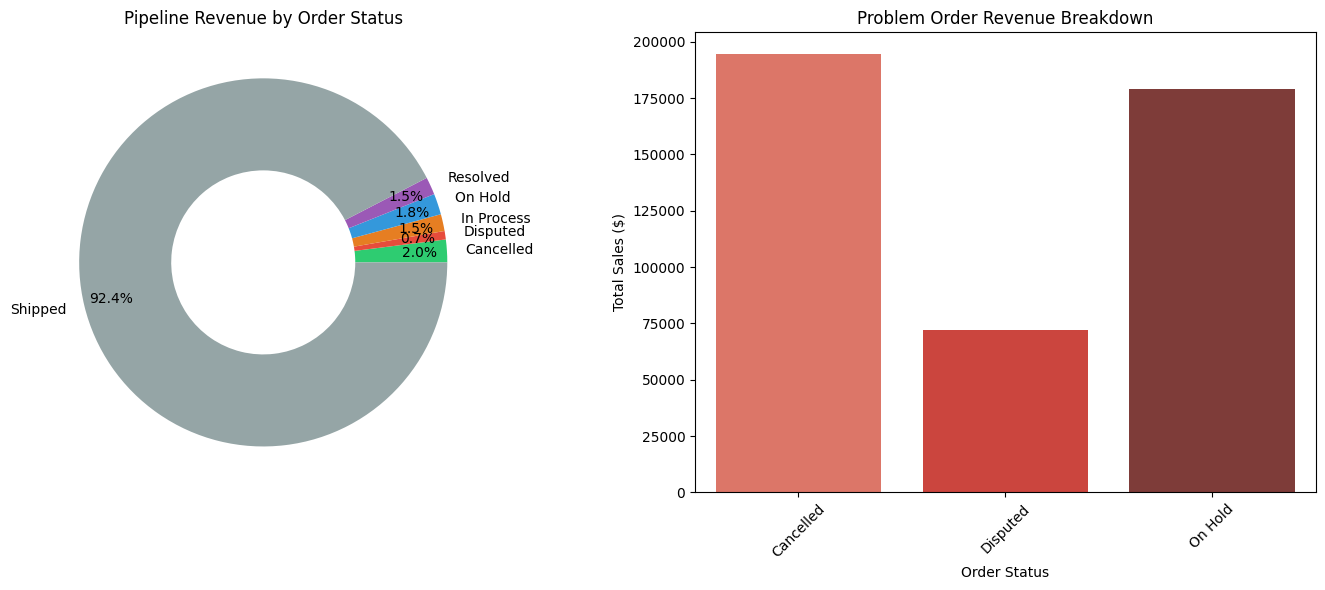

In [19]:
status_chart = df.groupby('STATUS').agg(
    order_count=('ORDERNUMBER', 'count'),
    total_sales=('SALES', 'sum')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db', '#9b59b6', '#95a5a6']
wedges, texts, autotexts = ax1.pie(
    status_chart['total_sales'],
    labels=status_chart['STATUS'],
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.85,
    wedgeprops=dict(width=0.5)
)
ax1.set_title('Pipeline Revenue by Order Status')

problem = status_chart[status_chart['STATUS'].isin(['Cancelled', 'Disputed', 'On Hold'])]
sns.barplot(data=problem, x='STATUS', y='total_sales', palette='Reds_d', ax=ax2, hue='STATUS', legend=False)
ax2.set_title('Problem Order Revenue Breakdown')
ax2.set_xlabel('Order Status')
ax2.set_ylabel('Total Sales ($)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Observation
The vast majority of revenue, roughly `$9,000,000`, comes from shipped orders, ensuring that the business is functioning properly. Looking deeper into problem orders (Cancelled, Disputed, and On Hold) these categories combined account for `4.5%`  of total revenue, roughly `$446,000`. Cancelled orders have the largest share at `2%`, followed by On Hold orders at `1.8%`, and Disputed at `0.7%`. Next, we'll group orders into broader categories to establish the headline problem order figure.

## 2. Pipeline Revenue by Category

Grouping orders into broader categories to establish a clear headline figure 
for problem order revenue across the pipeline.

In [10]:
category_map = {
    'Shipped': 'Completed Orders',
    'Resolved': 'Completed Orders',
    'Cancelled': 'Problem Orders',
    'Disputed': 'Problem Orders',
    'On Hold': 'Problem Orders',
    'In Process': 'Orders In Processing'
}

df['order_category'] = df['STATUS'].map(category_map)

category_breakdown = df.groupby('order_category').agg(
    order_count=('ORDERNUMBER', 'count'),
    total_sales=('SALES', 'sum')
).reset_index()

category_breakdown['percent_of_total'] = (
    category_breakdown['total_sales'] / category_breakdown['total_sales'].sum() * 100
).round(2)

category_breakdown = category_breakdown.sort_values('total_sales', ascending=False)

category_breakdown.rename(columns={
    'order_category': 'Order Category',
    'order_count': 'Order Count',
    'total_sales': 'Total Sales ($)',
    'percent_of_total': 'Share of Total (%)'
}, inplace=True)

category_breakdown.style.format({
    'Total Sales ($)': '{:,.2f}',
    'Share of Total (%)': '{:.2f}'
})

,Order Category,Order Count,Total Sales ($),Share of Total (%)
0,Completed Orders,2588,"9,169,812.22",93.95
2,Problem Orders,118,"445,679.53",4.57
1,Orders In Processing,41,"144,729.96",1.48


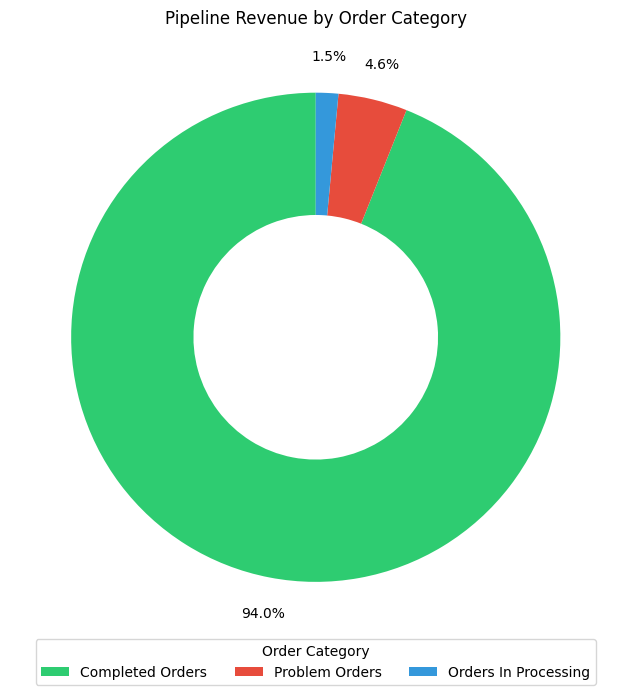

In [11]:
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    category_breakdown['Total Sales ($)'],
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops=dict(width=0.5),
    startangle=90,
    pctdistance=1.15
)
plt.legend(
    wedges,
    category_breakdown['Order Category'],
    title='Order Category',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3
)
plt.title('Pipeline Revenue by Order Category')
plt.tight_layout()
plt.show()

### Observation
Grouping all the orders into three distinct categories we have Completed Orders, Problem Orders, and Orders In Processing. The majority of orders are completed at `94%`. Problem orders are the next largest at `4.6%`, where orders that are currently being processed are just at `1.5%`. While a `94%` success rate is a respectable number, there is still room to improve and understand the reasoning behind problem orders. The following sections examine where these orders are concentrated geographically, by customer, and by product line.

## 3. Geographic Distribution of Problem Orders

Identifying which countries and regions have the highest concentration 
of problem orders to determine if there are geographic patterns driving 
cancellations, disputes, and holds.

In [20]:
problem_orders = df[df['STATUS'].isin(['Cancelled', 'Disputed', 'On Hold'])]

country_breakdown = problem_orders.groupby('COUNTRY').agg(
    order_count=('ORDERNUMBER', 'count'),
    total_sales=('SALES', 'sum')
).reset_index()

country_breakdown['percent_of_total'] = (
    country_breakdown['total_sales'] / country_breakdown['total_sales'].sum() * 100
).round(2)

country_breakdown = country_breakdown.sort_values('total_sales', ascending=False)

country_breakdown.rename(columns={
    'COUNTRY': 'Country',
    'order_count': 'Order Count',
    'total_sales': 'Total Sales ($)',
    'percent_of_total': 'Share of Problem Orders (%)'
}, inplace=True)

country_breakdown.style.format({
    'Total Sales ($)': '{:,.2f}',
    'Share of Problem Orders (%)': '{:.2f}'
})

,Country,Order Count,Total Sales ($),Share of Problem Orders (%)
5,USA,52,"198,076.64",44.44
2,Spain,22,"81,832.55",18.36
3,Sweden,22,"74,971.13",16.82
4,UK,14,"50,408.25",11.31
1,Denmark,3,"26,012.87",5.84
0,Australia,5,"14,378.09",3.23


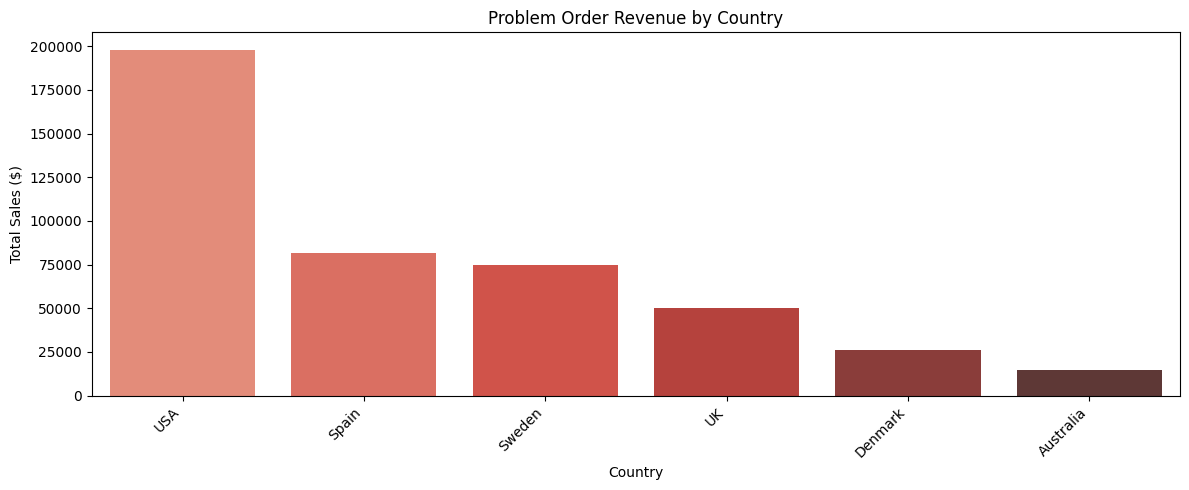

In [24]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=country_breakdown,
    x='Country',
    y='Total Sales ($)',
    palette='Reds_d',
    hue='Country',
    legend=False
)
plt.title('Problem Order Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observation
Looking into problem orders by geographic location it's clear there's a geographic concentration. The USA has the largest share of problem order revenue at around `$200,000`, almost `2.5x` the next highest countries. Spain and Sweden follow close to each other, at roughly `$82,000` and `$75,000`. The last three countries follow with the UK, Denmark, and Australia trailing significantly. The concentration of problem orders in the USA is notable, likely representing an overall larger market share. The next section will examine if specific customers in these regions are driving the pattern.

## 4. Problem Orders by Customer

Identifying which customers are repeatedly associated with problem orders 
to determine if specific relationships are driving a disproportionate share 
of cancellations, disputes, and holds.

In [25]:
customer_breakdown = problem_orders.groupby('CUSTOMERNAME').agg(
    order_count=('ORDERNUMBER', 'count'),
    total_sales=('SALES', 'sum')
).reset_index()

customer_breakdown['percent_of_total'] = (
    customer_breakdown['total_sales'] / customer_breakdown['total_sales'].sum() * 100
).round(2)

customer_breakdown = customer_breakdown.sort_values('total_sales', ascending=False).head(10)

customer_breakdown.rename(columns={
    'CUSTOMERNAME': 'Customer',
    'order_count': 'Order Count',
    'total_sales': 'Total Sales ($)',
    'percent_of_total': 'Share of Problem Orders (%)'
}, inplace=True)

customer_breakdown.style.format({
    'Total Sales ($)': '{:,.2f}',
    'Share of Problem Orders (%)': '{:.2f}'
})

,Customer,Order Count,Total Sales ($),Share of Problem Orders (%)
2,Euro Shopping Channel,22,"81,832.55",18.36
7,The Sharp Gifts Warehouse,12,"57,883.09",12.99
8,"UK Collectables, Ltd.",14,"50,408.25",11.31
5,Scandinavian Gift Ideas,16,"48,710.92",10.93
3,Gifts4AllAges.com,14,"48,316.89",10.84
6,Tekni Collectables Inc.,12,"46,519.00",10.44
4,Land of Toys Inc.,14,"45,357.66",10.18
9,"Volvo Model Replicas, Co",6,"26,260.21",5.89
1,Danish Wholesale Imports,3,"26,012.87",5.84
0,"Australian Collectables, Ltd",5,"14,378.09",3.23


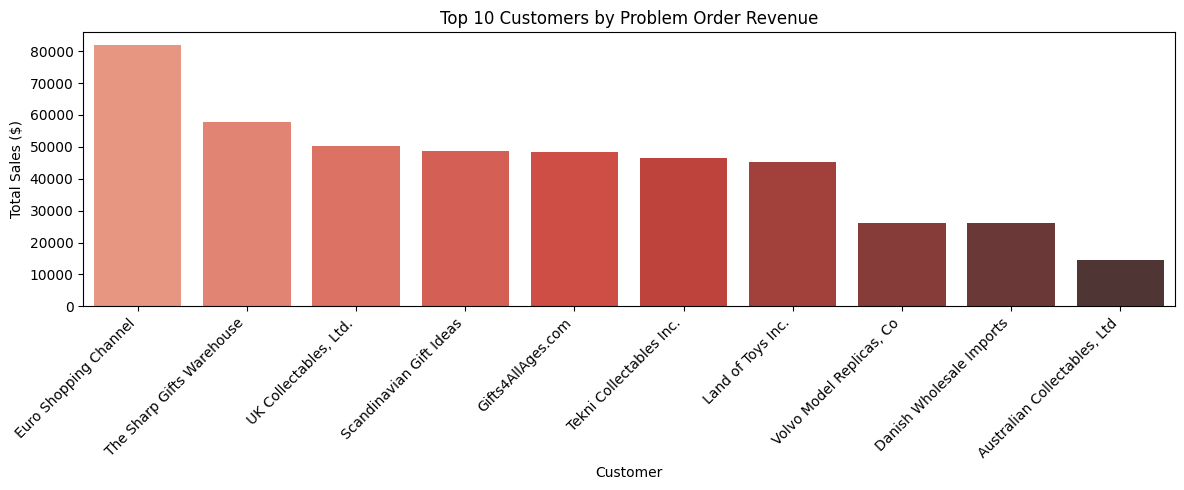

In [28]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=customer_breakdown,
    x='Customer',
    y='Total Sales ($)',
    palette='Reds_d',
    hue='Customer'
)
plt.title('Top 10 Customers by Problem Order Revenue')
plt.xlabel('Customer')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
repeat_offenders = problem_orders.groupby('CUSTOMERNAME').agg(
    total_orders=('ORDERNUMBER', 'count'),
    cancelled=('STATUS', lambda x: (x == 'Cancelled').sum()),
    disputed=('STATUS', lambda x: (x == 'Disputed').sum()),
    on_hold=('STATUS', lambda x: (x == 'On Hold').sum()),
    total_sales=('SALES', 'sum')
).reset_index()

repeat_offenders = repeat_offenders[repeat_offenders['total_orders'] > 1]
repeat_offenders = repeat_offenders.sort_values('total_orders', ascending=False).head(10)

repeat_offenders.rename(columns={
    'CUSTOMERNAME': 'Customer',
    'total_orders': 'Total Problem Orders',
    'cancelled': 'Cancelled',
    'disputed': 'Disputed',
    'on_hold': 'On Hold',
    'total_sales': 'Total Sales ($)'
}, inplace=True)

repeat_offenders.style.format({
    'Total Sales ($)': '{:,.2f}'
})

,Customer,Total Problem Orders,Cancelled,Disputed,On Hold,Total Sales ($)
2,Euro Shopping Channel,22,16,6,0,"81,832.55"
5,Scandinavian Gift Ideas,16,16,0,0,"48,710.92"
3,Gifts4AllAges.com,14,0,0,14,"48,316.89"
4,Land of Toys Inc.,14,14,0,0,"45,357.66"
8,"UK Collectables, Ltd.",14,14,0,0,"50,408.25"
6,Tekni Collectables Inc.,12,0,0,12,"46,519.00"
7,The Sharp Gifts Warehouse,12,0,0,12,"57,883.09"
9,"Volvo Model Replicas, Co",6,0,0,6,"26,260.21"
0,"Australian Collectables, Ltd",5,0,5,0,"14,378.09"
1,Danish Wholesale Imports,3,0,3,0,"26,012.87"


### Observation
Euro Shopping Channel has the highest problem order revenue at `$82,832`, followed by The Sharp Gifts Warehouse and UK Collectables, Ltd. Looking at repeat offenders, Euro Shopping Channel stands out again with 22 problem orders across Cancelled and Disputed categories, ssuggesting this is a pattern rather than a single incident from this customer. Highest priority action should be directed towards customers with high revenue and multiple problem order types. Occasional cancellations are common, but with repeated issues across all problem order categories, this points towards a relationship or fulfillment problem.

## 5. Product Line and Deal Size Analysis

Examining which product lines and deal sizes are most affected by problem 
orders to identify if certain products or order sizes carry a higher risk 
of cancellation, dispute, or delay.

In [22]:
product_breakdown = problem_orders.groupby('PRODUCTLINE').agg(
    order_count=('ORDERNUMBER', 'count'),
    total_sales=('SALES', 'sum')
).reset_index()

product_breakdown['percent_of_total'] = (
    product_breakdown['total_sales'] / product_breakdown['total_sales'].sum() * 100
).round(2)

product_breakdown = product_breakdown.sort_values('total_sales', ascending=False)

product_breakdown.rename(columns={
    'PRODUCTLINE': 'Product Line',
    'order_count': 'Order Count',
    'total_sales': 'Total Sales ($)',
    'percent_of_total': 'Share of Problem Orders (%)'
}, inplace=True)

product_breakdown.style.format({
    'Total Sales ($)': '{:,.2f}',
    'Share of Problem Orders (%)': '{:.2f}'
})

,Product Line,Order Count,Total Sales ($),Share of Problem Orders (%)
0,Classic Cars,31,"134,295.33",30.13
6,Vintage Cars,24,"86,080.76",19.31
3,Ships,27,"83,400.66",18.71
2,Planes,23,"74,004.08",16.60
1,Motorcycles,7,"36,814.51",8.26
5,Trucks and Buses,4,"20,193.29",4.53
4,Trains,2,"10,890.90",2.44


In [23]:
dealsize_breakdown = problem_orders.groupby(['PRODUCTLINE', 'DEALSIZE']).agg(
    order_count=('ORDERNUMBER', 'count')
).reset_index()

dealsize_pivot = dealsize_breakdown.pivot(
    index='PRODUCTLINE',
    columns='DEALSIZE',
    values='order_count'
).fillna(0).astype(int)

dealsize_pivot

DEALSIZE,Large,Medium,Small
PRODUCTLINE,,,
Classic Cars,5,15,11
Motorcycles,2,4,1
Planes,2,8,13
Ships,0,16,11
Trains,0,2,0
Trucks and Buses,0,3,1
Vintage Cars,1,14,9


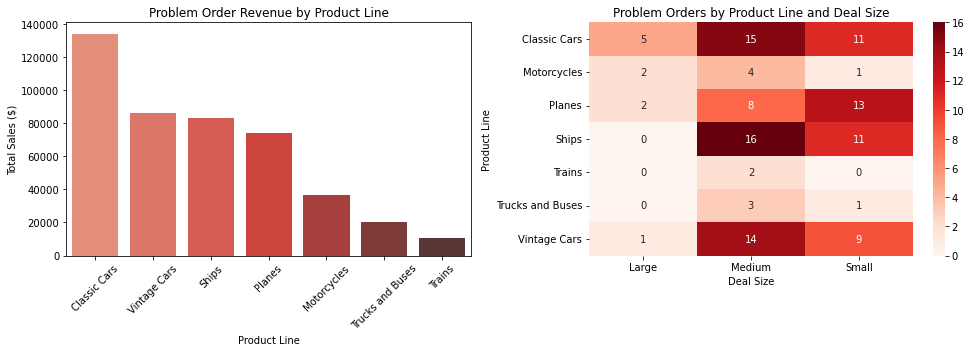

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left — problem order revenue by product line
sns.barplot(
    data=product_breakdown,
    x='Product Line',
    y='Total Sales ($)',
    palette='Reds_d',
    ax=ax1
)
ax1.set_title('Problem Order Revenue by Product Line')
ax1.set_xlabel('Product Line')
ax1.set_ylabel('Total Sales ($)')
ax1.tick_params(axis='x', rotation=45)

# Right — deal size heatmap
sns.heatmap(
    dealsize_pivot,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=ax2
)
ax2.set_title('Problem Orders by Product Line and Deal Size')
ax2.set_xlabel('Deal Size')
ax2.set_ylabel('Product Line')

plt.tight_layout()
plt.show()

### Observation
Classic Cars account for the largest share of problem order revenue at `30%`, roughly `$134,000` across 31 orders, this is the highest priority product line to investigate. Vintage Cars and Ships follow at both right around `19%`. 